<a href="https://colab.research.google.com/github/Gaurav-Rawool/Machin-learning/blob/main/Copy_of_ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Gaurav_Rawool , Batch-CE3, CE_39

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Display more readable NumPy output
np.set_printoptions(precision=4, suppress=True)

print("NumPy version:", np.__version__)

NumPy version: 2.0.2


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [8]:
from google.colab import files
import pandas as pd

# Upload the CSV file
uploaded = files.upload()

# Automatically get the uploaded filename
filename = next(iter(uploaded))

# Load the dataset
df = pd.read_csv(filename)

# Display first 5 records
display(df.head())

# Display shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Saving cardekho_dataset.csv to cardekho_dataset (5).csv


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


Number of rows: 15411
Number of columns: 14


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [9]:
# Task 3: Check and Handle Missing Data

# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

# Calculate total number of missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# Verify whether the dataset contains any missing values
print("\nDataset contains missing values:", df.isnull().values.any())

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0

Dataset contains missing values: False


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [10]:
selected_features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats',
    'seller_type',
    'fuel_type',
    'transmission_type'
]

X = df[selected_features].copy()
y = df['selling_price'].copy()

print("Selected features:")
print(selected_features)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Selected features:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'seller_type', 'fuel_type', 'transmission_type']

Feature matrix shape: (15411, 9)
Target shape: (15411,)


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [11]:
# Task 5: Encode Categorical Variables

# Define categorical columns
categorical_columns = [
    'seller_type',
    'fuel_type',
    'transmission_type'
]

# Convert categorical variables into dummy/indicator variables
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=float
)

# Display the transformed dataset
print("Encoded dataset:")
display(X_encoded.head())

# Display shape after encoding
print("\nShape after encoding:", X_encoded.shape)

# Check data types of all predictors
print("\nData types after encoding:")
print(X_encoded.dtypes)

# Verify that all predictors are numerical
print("\nAre all predictors numerical?",
      all(np.issubdtype(dtype, np.number) for dtype in X_encoded.dtypes))

Encoded dataset:


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,5,20000,18.90,1197,82.00,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,11,60000,17.00,1197,80.00,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,9,37000,20.92,998,67.10,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6,30000,22.77,1498,98.59,5,0.0,0.0,1.0,0.0,0.0,0.0,1.0



Shape after encoding: (15411, 13)

Data types after encoding:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
seller_type_Individual          float64
seller_type_Trustmark Dealer    float64
fuel_type_Diesel                float64
fuel_type_Electric              float64
fuel_type_LPG                   float64
fuel_type_Petrol                float64
transmission_type_Manual        float64
dtype: object

Are all predictors numerical? True


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [12]:
# Task 6: Perform Feature Engineering

# Create Car_Age from the existing vehicle_age column
current_year = 2026

df['Car_Age'] = df['vehicle_age']

# Display vehicle_age and newly created Car_Age
print("Vehicle age and Car_Age:")
display(df[['vehicle_age', 'Car_Age']].head(10))

# Check the range of Car_Age
print("\nMinimum car age:", df['Car_Age'].min())
print("Maximum car age:", df['Car_Age'].max())

# Select features for the regression model
selected_features = [
    'Car_Age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats',
    'seller_type',
    'fuel_type',
    'transmission_type'
]

# Create feature matrix and target variable
X = df[selected_features].copy()
y = df['selling_price'].copy()

# Encode categorical variables
X = pd.get_dummies(
    X,
    columns=['seller_type', 'fuel_type', 'transmission_type'],
    drop_first=True,
    dtype=float
)

# Display final feature matrix
print("\nFinal feature matrix:")
display(X.head())

print("\nFinal feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Vehicle age and Car_Age:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Minimum car age: 0
Maximum car age: 29

Final feature matrix:


,Car_Age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,5,20000,18.90,1197,82.00,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
2,11,60000,17.00,1197,80.00,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,9,37000,20.92,998,67.10,5,1.0,0.0,0.0,0.0,0.0,1.0,1.0
4,6,30000,22.77,1498,98.59,5,0.0,0.0,1.0,0.0,0.0,0.0,1.0



Final feature matrix shape: (15411, 13)
Target variable shape: (15411,)


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

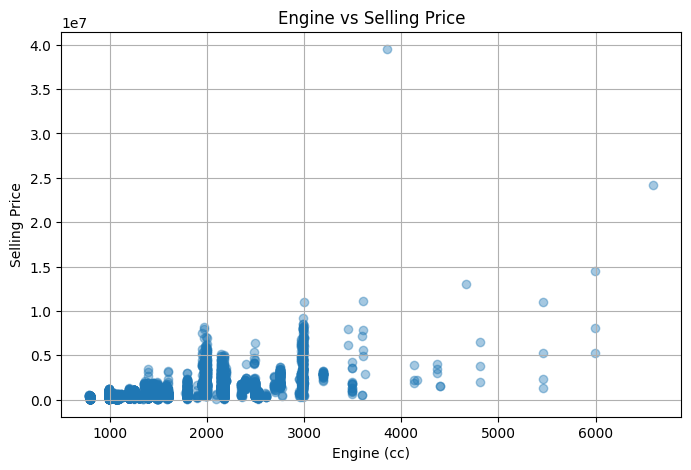

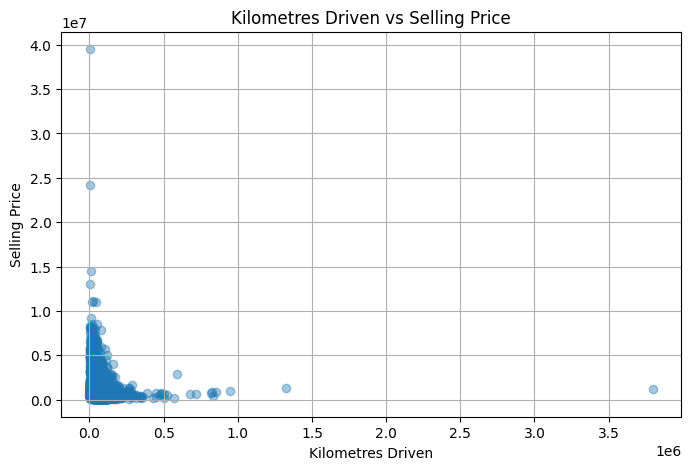

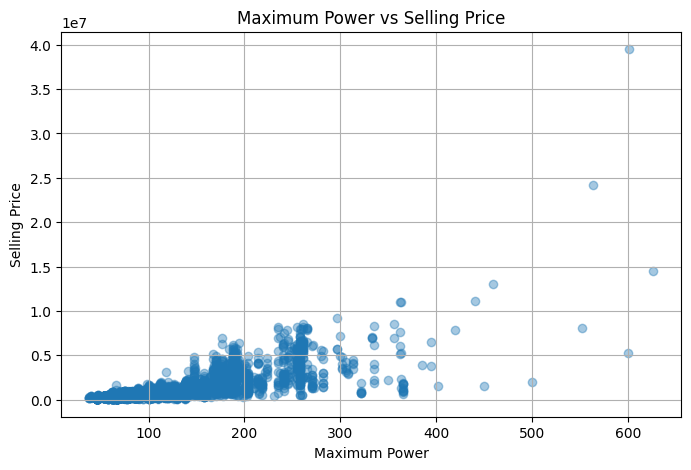

In [13]:
# Task 7: Perform Exploratory Data Analysis

# Plot 1: Engine vs Selling Price
plt.figure(figsize=(8, 5))
plt.scatter(
    df['engine'],
    df['selling_price'],
    alpha=0.4
)
plt.xlabel("Engine (cc)")
plt.ylabel("Selling Price")
plt.title("Engine vs Selling Price")
plt.grid(True)
plt.show()


# Plot 2: Kilometres Driven vs Selling Price
plt.figure(figsize=(8, 5))
plt.scatter(
    df['km_driven'],
    df['selling_price'],
    alpha=0.4
)
plt.xlabel("Kilometres Driven")
plt.ylabel("Selling Price")
plt.title("Kilometres Driven vs Selling Price")
plt.grid(True)
plt.show()


# Plot 3: Maximum Power vs Selling Price
plt.figure(figsize=(8, 5))
plt.scatter(
    df['max_power'],
    df['selling_price'],
    alpha=0.4
)
plt.xlabel("Maximum Power")
plt.ylabel("Selling Price")
plt.title("Maximum Power vs Selling Price")
plt.grid(True)
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [14]:
# Task 8: Standardize Numerical Features

# Convert X and y to NumPy arrays
X_array = X.values
y_array = y.values

# Set random seed for reproducibility
np.random.seed(42)

# Randomly shuffle the dataset indices
indices = np.random.permutation(len(X_array))

# Calculate 80% training size
train_size = int(0.80 * len(X_array))

# Create training and testing indices
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create training and testing datasets
Xtrain = X_array[train_indices]
Xtest = X_array[test_indices]

ytrain = y_array[train_indices]
ytest = y_array[test_indices]

# Numerical features that need standardization
numerical_features = [
    'Car_Age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

# Get the column positions of numerical features
feature_names = X.columns.tolist()

numerical_indices = [
    feature_names.index(feature)
    for feature in numerical_features
]

# Calculate mean and standard deviation using TRAINING DATA ONLY
train_means = Xtrain[:, numerical_indices].mean(axis=0)
train_stds = Xtrain[:, numerical_indices].std(axis=0)

# Create copies before standardization
Xtrain_scaled = Xtrain.copy()
Xtest_scaled = Xtest.copy()

# Standardize training numerical features
Xtrain_scaled[:, numerical_indices] = (
    Xtrain[:, numerical_indices] - train_means
) / train_stds

# Use the SAME training mean and standard deviation for test data
Xtest_scaled[:, numerical_indices] = (
    Xtest[:, numerical_indices] - train_means
) / train_stds

# Display results
print("Numerical features standardized:")
print(numerical_features)

print("\nTraining means:")
print(train_means)

print("\nTraining standard deviations:")
print(train_stds)

print("\nTraining data shape:", Xtrain_scaled.shape)
print("Testing data shape:", Xtest_scaled.shape)

# Verify standardized training features
print("\nMean after standardization:")
print(Xtrain_scaled[:, numerical_indices].mean(axis=0))

print("\nStandard deviation after standardization:")
print(Xtrain_scaled[:, numerical_indices].std(axis=0))

print("\nTarget variable was NOT standardized.")

Numerical features standardized:
['Car_Age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Training means:
[    6.0324 55692.8196    19.6916  1485.0374   100.5167     5.3262]

Training standard deviations:
[    3.0187 54470.9544     4.1726   518.276     42.744      0.8096]

Training data shape: (12328, 13)
Testing data shape: (3083, 13)

Mean after standardization:
[ 0.  0. -0.  0.  0. -0.]

Standard deviation after standardization:
[1. 1. 1. 1. 1. 1.]

Target variable was NOT standardized.


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [15]:
np.random.seed(42)

# Convert to NumPy arrays
X_array = X.values
y_array = y.values

# Number of observations
n = len(X_array)

# Randomly shuffle indices
indices = np.random.permutation(n)

# Calculate training size
train_size = int(0.80 * n)

# Split indices
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create train/test sets
Xtrain = X_array[train_indices]
Xtest = X_array[test_indices]

ytrain = y_array[train_indices]
ytest = y_array[test_indices]

print("Training observations:", len(Xtrain))
print("Testing observations:", len(Xtest))

Training observations: 12328
Testing observations: 3083


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [16]:
print("Xtrain shape:", Xtrain.shape)
print("ytrain shape:", ytrain.shape)

print("Xtest shape:", Xtest.shape)
print("ytest shape:", ytest.shape)

Xtrain shape: (12328, 13)
ytrain shape: (12328,)
Xtest shape: (3083, 13)
ytest shape: (3083,)


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [17]:
# Task 11: Add the Bias/Intercept Term

# Add a column of 1s to the training feature matrix
Xtrain_bias = np.column_stack([
    np.ones(Xtrain_scaled.shape[0]),
    Xtrain_scaled
])

# Add a column of 1s to the testing feature matrix
Xtest_bias = np.column_stack([
    np.ones(Xtest_scaled.shape[0]),
    Xtest_scaled
])

# Display matrix dimensions
print("Xtrain with bias:", Xtrain_bias.shape)
print("Xtest with bias:", Xtest_bias.shape)

# Display first 5 rows
print("\nFirst 5 rows of Xtrain with bias:")
print(Xtrain_bias[:5])

# The first column represents the intercept (β₀)
print("\nFirst column represents the intercept (β₀).")

Xtrain with bias: (12328, 14)
Xtest with bias: (3083, 14)

First 5 rows of Xtrain with bias:
[[ 1.      1.9768  0.3177  0.1602 -0.5558 -0.5057 -0.403   0.      0.
   0.      0.      0.      1.      1.    ]
 [ 1.     -0.6733  0.0424  1.845  -0.4574 -0.6204 -0.403   1.      0.
   1.      0.      0.      0.      1.    ]
 [ 1.      0.3205  0.74    0.2585 -0.4574 -0.2751  2.0675  0.      0.
   1.      0.      0.      0.      1.    ]
 [ 1.     -1.6671 -0.9398 -0.3095  0.025   0.4406 -0.403   0.      0.
   0.      0.      0.      1.      0.    ]
 [ 1.      1.6456  0.1158  0.002  -1.3295 -1.2684 -0.403   0.      0.
   0.      0.      0.      1.      1.    ]]

First column represents the intercept (β₀).


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [18]:
# Task 12: Implement Ordinary Least Squares (OLS)

def ols(X, y):
    # Calculate X^T X
    XTX = X.T @ X

    # Calculate X^T y
    XTy = X.T @ y

    # Calculate regression coefficients
    beta = np.linalg.inv(XTX) @ XTy

    return beta


# Apply OLS to the training data
beta = ols(Xtrain_bias, ytrain)

# Display the regression coefficient vector
print("Regression coefficient vector (β):")
print(beta)

# Display the dimensions
print("\nShape of coefficient vector:", beta.shape)

Regression coefficient vector (β):
[ 994217.8072 -195163.0905  -34965.026    62397.2944   48021.8183
  644333.4995    6812.1743   -6783.5554  -78002.6728 -124692.4296
  -96756.4105  358735.638  -119859.2156 -121450.2304]

Shape of coefficient vector: (14,)


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [19]:
# Task 13: Check Matrix Singularity

# Calculate X^T X
XTX = Xtrain_bias.T @ Xtrain_bias

# Calculate determinant of X^T X
det_XTX = np.linalg.det(XTX)

# Calculate condition number to check numerical stability
condition_number = np.linalg.cond(XTX)

# Display results
print("Determinant of X^T X:", det_XTX)
print("Condition number of X^T X:", condition_number)

# Check whether the matrix is singular or nearly singular
if np.isclose(det_XTX, 0):
    print("\nX^T X is singular or nearly singular.")
    print("The selected features may contain redundancy or multicollinearity.")
else:
    print("\nX^T X is not singular.")
    print("The matrix can be used for the OLS calculation.")

# Additional check using matrix rank
rank = np.linalg.matrix_rank(XTX)

print("\nMatrix rank:", rank)
print("Matrix size:", XTX.shape)

Determinant of X^T X: 4.028687647671399e+43
Condition number of X^T X: 11706.366913708265

X^T X is not singular.
The matrix can be used for the OLS calculation.

Matrix rank: 14
Matrix size: (14, 14)


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [20]:
# Task 14: Train the Regression Model

# Apply the OLS function to the training data
beta = ols(Xtrain_bias, ytrain)

# Create feature names including the intercept
feature_names_with_intercept = ['Intercept'] + feature_names

# Display the regression coefficients
print("Regression Coefficients:")
print("-" * 50)

for feature, coefficient in zip(feature_names_with_intercept, beta):
    print(f"{feature:30s} : {coefficient:,.4f}")

# Display the intercept separately
print("\nIntercept (β₀):", beta[0])

# Verify the number of coefficients
print("\nNumber of coefficients:", len(beta))
print("Number of features including intercept:", len(feature_names_with_intercept))

Regression Coefficients:
--------------------------------------------------
Intercept                      : 994,217.8072
Car_Age                        : -195,163.0905
km_driven                      : -34,965.0260
mileage                        : 62,397.2944
engine                         : 48,021.8183
max_power                      : 644,333.4995
seats                          : 6,812.1743
seller_type_Individual         : -6,783.5554
seller_type_Trustmark Dealer   : -78,002.6728
fuel_type_Diesel               : -124,692.4296
fuel_type_Electric             : -96,756.4105
fuel_type_LPG                  : 358,735.6380
fuel_type_Petrol               : -119,859.2156
transmission_type_Manual       : -121,450.2304

Intercept (β₀): 994217.8072436415

Number of coefficients: 14
Number of features including intercept: 14


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [21]:
# Task 15: Interpret the Regression Coefficients

# Create a coefficient table
coefficient_table = pd.DataFrame({
    'Feature': feature_names_with_intercept,
    'Coefficient': beta
})

# Determine whether each coefficient is positive or negative
coefficient_table['Effect'] = np.where(
    coefficient_table['Coefficient'] > 0,
    'Positive',
    'Negative'
)

# Calculate absolute coefficient magnitude
coefficient_table['Absolute_Coefficient'] = (
    coefficient_table['Coefficient'].abs()
)

# Sort by absolute coefficient to identify relatively influential features
coefficient_table = coefficient_table.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

# Display coefficient table
print("Regression Coefficient Interpretation:")
display(coefficient_table)

# Display positive and negative features
print("\nPositive coefficients:")
print(
    coefficient_table[
        coefficient_table['Coefficient'] > 0
    ][['Feature', 'Coefficient']]
)

print("\nNegative coefficients:")
print(
    coefficient_table[
        coefficient_table['Coefficient'] < 0
    ][['Feature', 'Coefficient']]
)

# Identify the most influential features
print("\nMost influential features based on absolute coefficient:")
display(
    coefficient_table[
        coefficient_table['Feature'] != 'Intercept'
    ].head(5)[['Feature', 'Coefficient', 'Absolute_Coefficient']]
)

Regression Coefficient Interpretation:


,Feature,Coefficient,Effect,Absolute_Coefficient
0,Intercept,994217.807244,Positive,994217.807244
5,max_power,644333.499455,Positive,644333.499455
11,fuel_type_LPG,358735.637965,Positive,358735.637965
1,Car_Age,-195163.090535,Negative,195163.090535
9,fuel_type_Diesel,-124692.429563,Negative,124692.429563
13,transmission_type_Manual,-121450.230376,Negative,121450.230376
12,fuel_type_Petrol,-119859.215609,Negative,119859.215609
10,fuel_type_Electric,-96756.410532,Negative,96756.410532
8,seller_type_Trustmark Dealer,-78002.672818,Negative,78002.672818
3,mileage,62397.294362,Positive,62397.294362



Positive coefficients:
          Feature    Coefficient
0       Intercept  994217.807244
5       max_power  644333.499455
11  fuel_type_LPG  358735.637965
3         mileage   62397.294362
4          engine   48021.818297
6           seats    6812.174317

Negative coefficients:
                         Feature    Coefficient
1                        Car_Age -195163.090535
9               fuel_type_Diesel -124692.429563
13      transmission_type_Manual -121450.230376
12              fuel_type_Petrol -119859.215609
10            fuel_type_Electric  -96756.410532
8   seller_type_Trustmark Dealer  -78002.672818
2                      km_driven  -34965.026012
7         seller_type_Individual   -6783.555363

Most influential features based on absolute coefficient:


,Feature,Coefficient,Absolute_Coefficient
5,max_power,644333.499455,644333.499455
11,fuel_type_LPG,358735.637965,358735.637965
1,Car_Age,-195163.090535,195163.090535
9,fuel_type_Diesel,-124692.429563,124692.429563
13,transmission_type_Manual,-121450.230376,121450.230376


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [22]:
# Task 16: Predict Selling Prices

# Predict selling prices for the test dataset
y_pred = Xtest_bias @ beta

# Create a comparison table
comparison = pd.DataFrame({
    'Actual Selling Price': ytest,
    'Predicted Selling Price': y_pred
})

# Display first 10 actual vs predicted values
print("Actual vs Predicted Selling Prices:")
display(comparison.head(10))

# Calculate prediction error
comparison['Prediction Error'] = (
    comparison['Actual Selling Price'] -
    comparison['Predicted Selling Price']
)

# Display basic prediction information
print("\nNumber of predictions:", len(y_pred))
print("Minimum predicted price:", y_pred.min())
print("Maximum predicted price:", y_pred.max())

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4450000,2.046440e+06
1,1290000,1.431418e+06
2,485000,3.390972e+05
3,400000,5.432682e+05
4,800000,8.623530e+05
5,150000,-6.165112e+05
6,650000,8.209350e+05
7,325000,-1.758146e+05
8,300000,3.786409e+05
9,925000,7.769197e+05



Number of predictions: 3083
Minimum predicted price: -968102.3265351715
Maximum predicted price: 8434192.825700272


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [23]:
# Task 17: Calculate Prediction Errors and RSS

# Calculate residuals (prediction errors)
residuals = ytest - y_pred

# Calculate Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

# Display first 10 residuals
print("First 10 prediction errors (residuals):")
print(residuals[:10])

# Display RSS
print("\nResidual Sum of Squares (RSS):")
print(RSS)

# Calculate Mean Squared Error for additional interpretation
MSE = RSS / len(ytest)

print("\nMean Squared Error (MSE):")
print(MSE)

# Calculate Root Mean Squared Error
RMSE = np.sqrt(MSE)

print("\nRoot Mean Squared Error (RMSE):")
print(RMSE)

First 10 prediction errors (residuals):
[2403559.514  -141417.8128  145902.819  -143268.1989  -62352.9817
  766511.2216 -170934.9971  500814.5513  -78640.9174  148080.2689]

Residual Sum of Squares (RSS):
885105657669986.8

Mean Squared Error (MSE):
287092331388.2539

Root Mean Squared Error (RMSE):
535809.9769398232


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [24]:
# Task 18: Calculate and Interpret R²

# Calculate Total Sum of Squares (TSS)
TSS = np.sum((ytest - np.mean(ytest)) ** 2)

# Calculate R²
R2 = 1 - (RSS / TSS)

# Display TSS and R²
print("Total Sum of Squares (TSS):")
print(TSS)

print("\nR² Score:")
print(R2)

# Display R² as a percentage
print("\nR² Percentage:")
print(R2 * 100, "%")

# Interpretation
if R2 >= 0:
    print("\nInterpretation:")
    print(
        f"The model explains approximately {R2 * 100:.2f}% "
        "of the variation in used-car selling prices."
    )
else:
    print("\nInterpretation:")
    print(
        "The model has an R² value below zero, indicating that "
        "it performs worse than simply predicting the mean selling price."
    )

Total Sum of Squares (TSS):
2407385049859876.5

R² Score:
0.6323373123375071

R² Percentage:
63.23373123375071 %

Interpretation:
The model explains approximately 63.23% of the variation in used-car selling prices.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


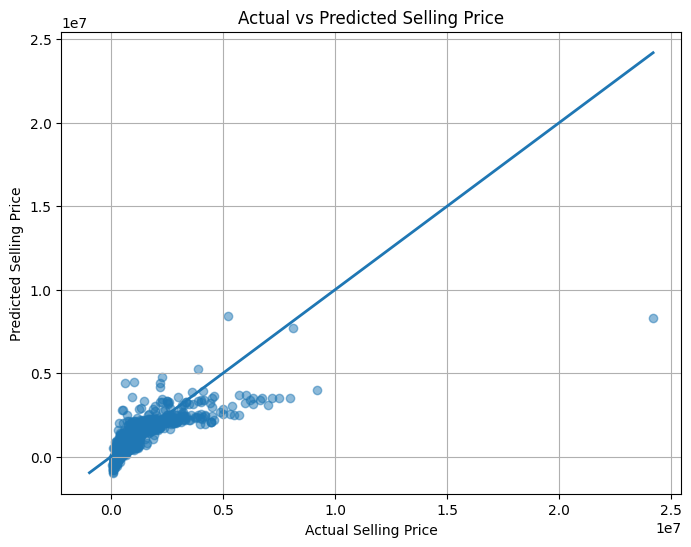

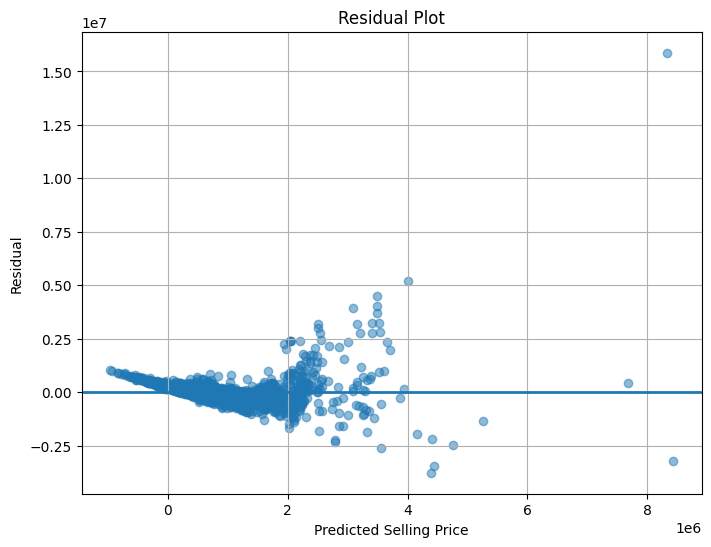

10 observations with the largest prediction errors:


,Actual Selling Price,Predicted Selling Price,Residual,Absolute Error
2796,24200000,8.323205e+06,1.587679e+07,1.587679e+07
2362,9200000,4.009019e+06,5.190981e+06,5.190981e+06
1382,8000000,3.488917e+06,4.511083e+06,4.511083e+06
841,7500000,3.485714e+06,4.014286e+06,4.014286e+06
246,7000000,3.084722e+06,3.915278e+06,3.915278e+06
26,625000,4.390874e+06,-3.765874e+06,3.765874e+06
1286,7199000,3.488917e+06,3.710083e+06,3.710083e+06
2528,999000,4.439605e+06,-3.440605e+06,3.440605e+06
2050,5200000,8.434193e+06,-3.234193e+06,3.234193e+06
1092,6645000,3.412468e+06,3.232532e+06,3.232532e+06



Mean Absolute Error (MAE): 266187.96129993134


In [25]:
# Task 19: Visualize and Analyze Model Performance

# Create Actual vs Predicted Selling Price plot
plt.figure(figsize=(8, 6))

plt.scatter(
    ytest,
    y_pred,
    alpha=0.5
)

# Reference line for perfect prediction
min_price = min(ytest.min(), y_pred.min())
max_price = max(ytest.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linewidth=2
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.grid(True)
plt.show()


# Create residual plot
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

# Reference line at zero residual
plt.axhline(
    0,
    linewidth=2
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


# Identify observations with the largest prediction errors
error_table = pd.DataFrame({
    'Actual Selling Price': ytest,
    'Predicted Selling Price': y_pred,
    'Residual': residuals,
    'Absolute Error': np.abs(residuals)
})

large_errors = error_table.sort_values(
    'Absolute Error',
    ascending=False
).head(10)

print("10 observations with the largest prediction errors:")
display(large_errors)


# Display average absolute error
MAE = np.mean(np.abs(residuals))

print("\nMean Absolute Error (MAE):", MAE)

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.